# PROYEK DATA SAINS: ANALISIS INTEGRASI AKHIR
## *Telecom Customer Churn - Final Integration (Revisi)*

**Data Preprocessing, Feature Engineering, dan Exploratory Data Analysis (EDA) untuk Persiapan Model Prediksi Customer Churn pada Industri Telekomunikasi**

---

## Kelompok 2
> * **Alya Dhamierea Islamay Putri** — `255150700111019`
> * **Aisyah Berlianti Afriandi** — `255150700111022`
> * **Salma Ninda Syahputri** — `255150701111024`
> * **I Dewa Ayu Puspa Dewi** — `255150700111045`

**GitHub Repository :** [Telecom-Churn-Rate_Kelompok-2](https://github.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2)

**Dataset :** Telecom Customer Churn Feature Engineering Dataset

---

### Catatan Revisi
Notebook ini merupakan revisi dari integrasi sebelumnya, disesuaikan dengan perubahan pada:
- **Notebook A:** Metode segmentasi diperbarui dari pendekatan kuadran berbasis median menjadi **K-Means Clustering**, fokus analisis diperdalam pada perspektif churn, serta profil persona diperbarui berdasarkan hasil clustering.
- **Notebook B:** Seluruh analisis direvisi. Subset `df_churn` digunakan untuk analisis diagnostik, visualisasi komparatif diganti ke scatter plot, rekomendasi berbasis data feedback, dan struktur dirapikan.
- **Notebook C:** Beberapa bagian analisis diperbarui termasuk penanganan data dan visualisasi finansial.
- **Notebook D:** URL sumber data diperbarui ke direktori revisi terbaru.


# 1. Project Overview

## Oleh: **Alya Dhamierea Islamay Putri** — `255150700111019`
Notebook ini merupakan integrasi seluruh hasil analisis yang telah dilakukan oleh Kelompok 2 dalam proyek prediksi *customer churn* industri telekomunikasi Pakistan. Dataset mentah telah melalui proses **Data Preprocessing** dan **Feature Engineering** secara menyeluruh di notebook D Master (revisi), menghasilkan dataset bersih yang selanjutnya digunakan oleh seluruh anggota tim.

| Notebook | Anggota | Fokus Analisis | Perubahan Revisi |
| :------- | :------ | :-------------- | :---------------- |
| **A** | Aisyah Berlianti Afriandi | Customer Segmentation — K-Means Clustering & Wasted Value | Metode: if-else median → K-Means; fokus churn diperdalam |
| **B** | I Dewa Ayu Puspa Dewi | Service Quality & Pain Points | Seluruh analisis direvisi; subset df_churn; scatter plot |
| **C** | Salma Ninda Syahputri | Financial Sensitivity Analysis | Beberapa bagian diperbarui |
| **D** | Alya Dhamierea Islamay Putri | Preprocessing & General EDA | URL sumber data diperbarui |

---

# 2. Load Dataset Final

Dataset yang digunakan adalah `telecom_clean.csv`, hasil akhir preprocessing dari D Master (revisi). Dataset ini telah melewati seluruh tahapan pembersihan data, feature engineering, encoding, scaling, dan capping.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

url = 'https://raw.githubusercontent.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2/refs/heads/main/TELECOM_CHURN_RATE_REVISI/data/telecome_clean.csv'
df = pd.read_csv(url)

print(f'Dataset berhasil dimuat.')
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')
df.head()

Dataset berhasil dimuat.
Jumlah baris  : 1,200
Jumlah kolom  : 42


,gender,churn,monthly_bill_capped,internet_usage_gb_capped,call_minutes_capped,support_tickets_capped,tenure_months,financial_risk,education_level_encoded,contract_type_encoded,...,city_Gujranwala,city_Hyderabad,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Peshawar,city_Quetta,city_Rawalpindi,city_Sialkot
0,1,0,10049.0,5.8,52.0,1,91,0,2,1,...,0,0,0,0,0,1,0,0,0,0
1,0,0,2752.0,11.9,22.0,2,91,0,3,1,...,0,0,0,0,0,0,1,0,0,0
2,1,0,3155.0,40.0,87.0,0,91,0,1,0,...,1,0,0,0,0,0,0,0,0,0
3,1,0,5859.0,8.5,147.0,2,90,0,1,1,...,0,0,0,0,1,0,0,0,0,0
4,0,0,5106.0,3.3,183.0,0,90,0,0,2,...,0,1,0,0,0,0,0,0,0,0


# 3. Ringkasan Dataset

Dataset final terdiri atas **1.200 pelanggan** dengan **42 kolom** yang mencakup fitur demografi, penggunaan layanan, kondisi finansial, serta fitur-fitur hasil rekayasa. Tidak terdapat nilai kosong di seluruh kolom dataset.


In [4]:
print('=== RINGKASAN DATASET ===')
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')
print(f'Missing values: {df.isnull().sum().sum()}')
print()
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100
print('=== DISTRIBUSI TARGET (churn) ===')
print(f'  Non-Churn (0) : {churn_counts[0]:>4}  ({churn_pct[0]:.1f}%)')
print(f'  Churn     (1) : {churn_counts[1]:>4}  ({churn_pct[1]:.1f}%)')

=== RINGKASAN DATASET ===
Jumlah baris  : 1,200
Jumlah kolom  : 42
Missing values: 0

=== DISTRIBUSI TARGET (churn) ===
  Non-Churn (0) :  780  (65.0%)
  Churn     (1) :  420  (35.0%)


### Interpretasi

Dari 1.200 pelanggan, sebanyak **420 pelanggan (35%)** telah melakukan *churn*, sementara **780 pelanggan (65%)** masih aktif. Proporsi churn yang mencapai sepertiga populasi merupakan angka signifikan secara bisnis.

---

# 4. Ringkasan General EDA

*(Hasil dari D Master — Preprocessing & General EDA, URL sumber data diperbarui)*

General EDA yang dilakukan di notebook D Master (revisi) mengungkap karakteristik penting dataset. Perubahan pada revisi ini adalah pembaruan URL sumber data ke direktori `TELECOM_CHURN_RATE_REVISI` di repositori GitHub kelompok.

**Demografi Pelanggan:**
- Distribusi usia pelanggan relatif merata antara 18 hingga 69 tahun, dengan rata-rata 43,5 tahun.
- Komposisi gender seimbang: 603 pelanggan laki-laki (50,3%) dan 597 perempuan (49,7%).
- Pelanggan tersebar di 11 kota di Pakistan.

**Penggunaan Layanan:**
- Rata-rata penggunaan internet sebesar 20,15 GB per bulan.
- Rata-rata durasi panggilan sebesar 182,8 menit per bulan.
- Mayoritas pelanggan menggunakan jenis kontrak bulanan (*Monthly*).

**Kondisi Finansial:**
- Rata-rata tagihan bulanan sebesar 5.939 dengan variasi cukup tinggi.
- Outlier ekstrem telah ditangani melalui capping berbasis IQR.

**Variabel Anomali (Feature Engineering):**
- `anomaly_happy_leaver`: 21 pelanggan churn tanpa riwayat keluhan.
- `anomaly_genz_call_enthusiast`: 121 pelanggan muda (≤27 tahun) dengan durasi telepon tinggi.

---

# 5. Ringkasan Analisis A — Customer Segmentation

### Perubahan Utama dari Versi Sebelumnya

Versi sebelumnya menggunakan pendekatan **kuadran berbasis nilai median** (if-else manual) untuk membagi pelanggan ke dalam 4 segmen. Pada revisi ini, metode diganti dengan **K-Means Clustering** menggunakan algoritma machine learning yang lebih objektif, dengan jumlah cluster K=4 yang ditentukan menggunakan **Elbow Method**. Perubahan ini membuat segmentasi lebih berbasis data dan tidak bergantung pada asumsi ambang batas yang ditentukan secara manual.

### Fokus Analisis

Analisis A berfokus pada **Behavioral Matrix** dan **Wasted Value Analysis** menggunakan tiga variabel utama: `internet_usage_gb`, `call_minutes`, dan `monthly_bill`. Variabel `churn` disertakan sebagai variabel target untuk memvalidasi hubungan antara karakteristik penggunaan dan kecenderungan berhenti berlangganan.

### Temuan Utama: Empat Persona dari K-Means

Berdasarkan hasil K-Means Clustering, pelanggan terbagi ke dalam empat segmen dengan karakteristik sebagai berikut:

| Segmen | Nama Persona | Karakteristik | Churn Rate | Tagihan Rata-rata |
| :----- | :----------- | :------------ | :--------- | :----------------- |
| Segmen 0 | Casual User | Internet 13,89 GB, Telepon 135 menit | ~35% | 4.828 |
| Segmen 1 | High-Paying Victims | Internet 18,90 GB, Telepon 186 menit | **57%** | **14.950** |
| Segmen 2 | Traditional Communicator | Internet 16,67 GB, Telepon 349 menit | ~39% | 5.254 |
| Segmen 3 | Digital Native | Internet **36,76 GB**, Telepon rendah | **29%** | 4.911 |

Temuan kritis dari K-Means: **Segmen 1 (High-Paying Victims)** membayar tagihan hampir 3x lipat segmen lain (14.950) meskipun pemakaian internet dan teleponnya hanya rata-rata. Ketidaksesuaian antara nilai yang dibayarkan dengan nilai yang diterima (*wasted value*) menjadi pemicu churn rate tertinggi di angka **57%**.

Sebaliknya, **Segmen 3 (Digital Native)** adalah segmen paling loyal dengan churn rate terendah (29%) karena mendapatkan *value* maksimal: kuota internet besar (36,76 GB) dengan harga terjangkau (4.911).


In [5]:
# Replikasi K-Means Segmentation dari Notebook A
seg_cols = ['internet_usage_gb', 'call_minutes', 'monthly_bill']

# Validasi kolom — gunakan versi capped jika kolom asli tidak tersedia
available_cols = []
col_map = {'internet_usage_gb': 'internet_usage_gb_capped',
           'call_minutes': 'call_minutes_capped',
           'monthly_bill': 'monthly_bill_capped'}
for c in seg_cols:
    if c in df.columns:
        available_cols.append(c)
    elif col_map[c] in df.columns:
        available_cols.append(col_map[c])

seg_df = df[available_cols].copy()
target_churn = df['churn'].copy()

# Standardisasi
scaler = StandardScaler()
seg_scaled = pd.DataFrame(scaler.fit_transform(seg_df), columns=seg_df.columns)

# K-Means K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(seg_scaled)
seg_df['Cluster'] = kmeans.labels_
seg_df['churn']   = target_churn.values

# Ringkasan cluster
cluster_summary = seg_df.groupby('Cluster').agg(
    {available_cols[0]: 'mean', available_cols[1]: 'mean', available_cols[2]: 'mean',
     'churn': ['mean', 'count']}
).round(2)
cluster_summary.columns = ['Avg_Internet_GB', 'Avg_Call_Minutes', 'Avg_Monthly_Bill', 'Churn_Rate', 'Total']
cluster_summary['Churn_Rate'] = (cluster_summary['Churn_Rate'] * 100).round(1)
display(cluster_summary)

,Avg_Internet_GB,Avg_Call_Minutes,Avg_Monthly_Bill,Churn_Rate,Total
Cluster,,,,,
0,16.72,321.93,4845.00,33.0,216
1,36.33,161.26,4481.61,26.0,251
2,18.57,173.55,10531.07,51.0,265
3,13.46,127.82,4036.88,32.0,468


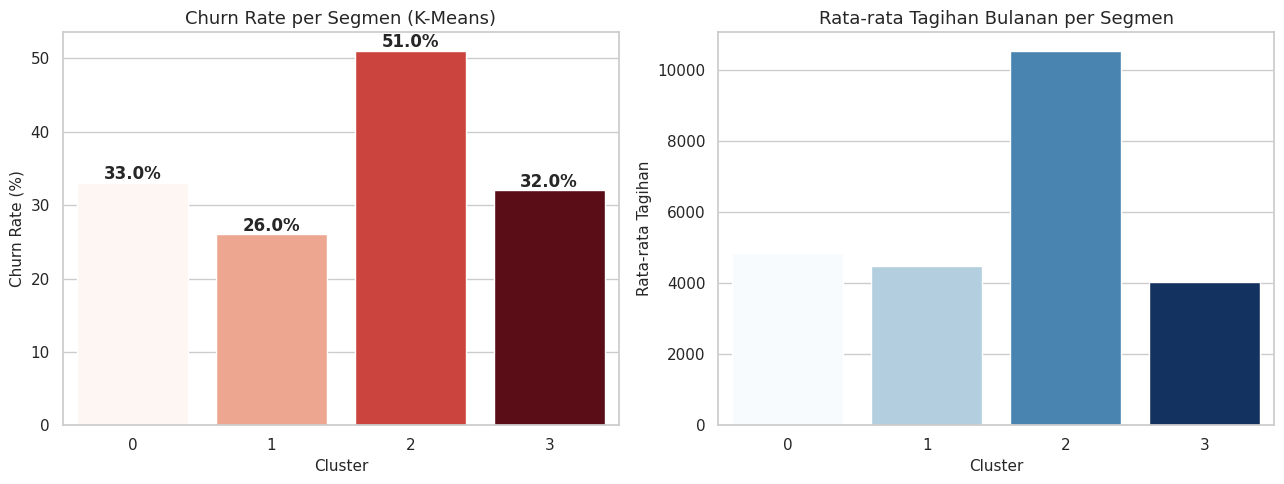

In [6]:
# Visualisasi: Churn Rate per Segmen K-Means
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Churn rate tiap segmen
sns.barplot(x=cluster_summary.index, y=cluster_summary['Churn_Rate'],
            palette='Reds', ax=axes[0], hue=cluster_summary.index, legend=False)
for i, val in enumerate(cluster_summary['Churn_Rate']):
    axes[0].text(i, val + 0.5, f'{val}%', ha='center', fontweight='bold')
axes[0].set_title('Churn Rate per Segmen (K-Means)')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Churn Rate (%)')

# Panel 2: Rata-rata tagihan tiap segmen
sns.barplot(x=cluster_summary.index, y=cluster_summary['Avg_Monthly_Bill'],
            palette='Blues', ax=axes[1], hue=cluster_summary.index, legend=False)
axes[1].set_title('Rata-rata Tagihan Bulanan per Segmen')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Rata-rata Tagihan')

plt.tight_layout()
plt.show()

### Interpretasi

Hasil K-Means mengonfirmasi hipotesis *wasted value* dengan lebih tajam dibanding metode kuadran sebelumnya. Segmen 1 (*High-Paying Victims*) memiliki tagihan yang anomali tinggi (14.950) meskipun pola penggunaannya biasa saja, yang secara langsung berkorelasi dengan churn rate tertinggi (57%). Ini adalah sinyal bisnis yang paling kritis: ketidaksesuaian harga-nilai adalah pemicu utama churn pada segmen ini.

Profil *ringkasan persona* yang diperbarui berdasarkan K-Means:
- **Traditional Communicator** (Segmen 2) memiliki churn rate mengkhawatirkan (39%) dengan kontribusi pendapatan tertinggi — segmen prioritas retensi.
- **Digital Native** (Segmen 3) adalah aset paling stabil (churn 29%) karena mendapat value tertinggi.
- **Casual User** (Segmen 0, 602 pelanggan) adalah kelompok mayoritas dengan perilaku penggunaan paling standar.

---

# 6. Ringkasan Analisis B — Service Quality & Pain Points

### Perubahan Utama dari Versi Sebelumnya

| Aspek | Versi Lama | Versi Revisi |
| :---- | :--------- | :----------- |
| Scope data | Seluruh 1.200 pelanggan | Subset `df_churn` (420 pelanggan) untuk analisis diagnostik |
| Visualisasi komparatif | Histogram/boxplot per kelompok | Scatter plot interaksi dua variabel |
| Rekomendasi | Berbasis opini umum | Berbasis kuantifikasi data feedback |
| Struktur | Langsung ke eksplorasi | Ditambah pendahuluan, peta analisis, dan interpretasi sistematis |

### Metodologi: Dua Tahapan Analisis

Notebook B kini dibedakan menjadi dua tahapan yang jelas:
1. **Analisis Konfirmatif** — menggunakan seluruh dataset untuk membandingkan pelanggan churn vs non-churn.
2. **Analisis Diagnostik** — menggunakan subset `df_churn` (420 baris) untuk menggambarkan karakteristik *pain points* populasi churn secara spesifik.

### Temuan Utama

**1. Support Tickets sebagai Prediktor Churn Paling Konsisten**
Pelanggan yang churn rata-rata mengajukan **2,1 tiket keluhan**, hampir tiga kali lipat pelanggan aktif (0,69). Variabel ini menunjukkan korelasi positif paling kuat terhadap `churn_status` di antara seluruh variabel kualitas layanan yang dianalisis.

**2. Dominasi Kontrak Monthly pada Populasi Churn**
Sekitar **70% pelanggan churn** memiliki kontrak *Monthly* — konsisten di berbagai kota. Kontrak bulanan memberikan fleksibilitas tinggi untuk keluar, sehingga hambatan berpindah sangat rendah.

**3. Jaringan/Sinyal sebagai Pain Point Utama**
Berdasarkan analisis `feedback_category` pada 420 pelanggan churn, distribusinya adalah:
- **Jaringan/Sinyal**: ~42% (dominan)
- **Positif/Puas** (Happy Leaver): ~29%
- **Biaya/Tagihan**: ~21%
- **Customer Support**: ~9%

**4. Fenomena Happy Leaver**
~29% pelanggan churn memberikan feedback positif sebelum berhenti — mengindikasikan faktor lain di luar kualitas layanan (penawaran kompetitor, perubahan kebutuhan) yang belum terwakili dalam data.

**5. Variasi Geografis**
Lahore, Peshawar, dan Gujranwala mencatat jumlah pelanggan churn absolut tertinggi.


In [7]:
# Replikasi analisis subset df_churn dari Notebook B (revisi)
df_b = df.rename(columns={'churn': 'churn_status'}).copy()

# Rekonstruksi nama kota
city_cols = [c for c in df_b.columns if c.startswith('city_')]
df_b['city_name'] = df_b[city_cols].idxmax(axis=1).str.replace('city_', '')

# Label kontrak
df_b['contract_label'] = df_b['contract_type_encoded'].map({0: 'Monthly', 1: '6 Month', 2: '12 Month'})

# Subset churn
df_churn_b = df_b[df_b['churn_status'] == 1].copy()

# Label feedback
fb_map = {0: 'Biaya/Tagihan', 1: 'Jaringan/Sinyal', 2: 'Customer Support', 3: 'Positif/Puas'}
df_churn_b['feedback_label'] = df_churn_b['feedback_category'].map(fb_map)

print(f'Populasi churn: {len(df_churn_b)} pelanggan')
print()
print('=== Distribusi Feedback pada Populasi Churn ===')
fb_dist = df_churn_b['feedback_label'].value_counts(normalize=True).mul(100).round(1)
print(fb_dist.to_string())
print()
print('=== Distribusi Kontrak pada Populasi Churn ===')
ct_dist = df_churn_b['contract_label'].value_counts(normalize=True).mul(100).round(1)
print(ct_dist.to_string())

Populasi churn: 420 pelanggan

=== Distribusi Feedback pada Populasi Churn ===
feedback_label
Jaringan/Sinyal     42.1
Positif/Puas        28.6
Biaya/Tagihan       20.5
Customer Support     8.8

=== Distribusi Kontrak pada Populasi Churn ===
contract_label
Monthly     70.5
6 Month     15.0
12 Month    14.5


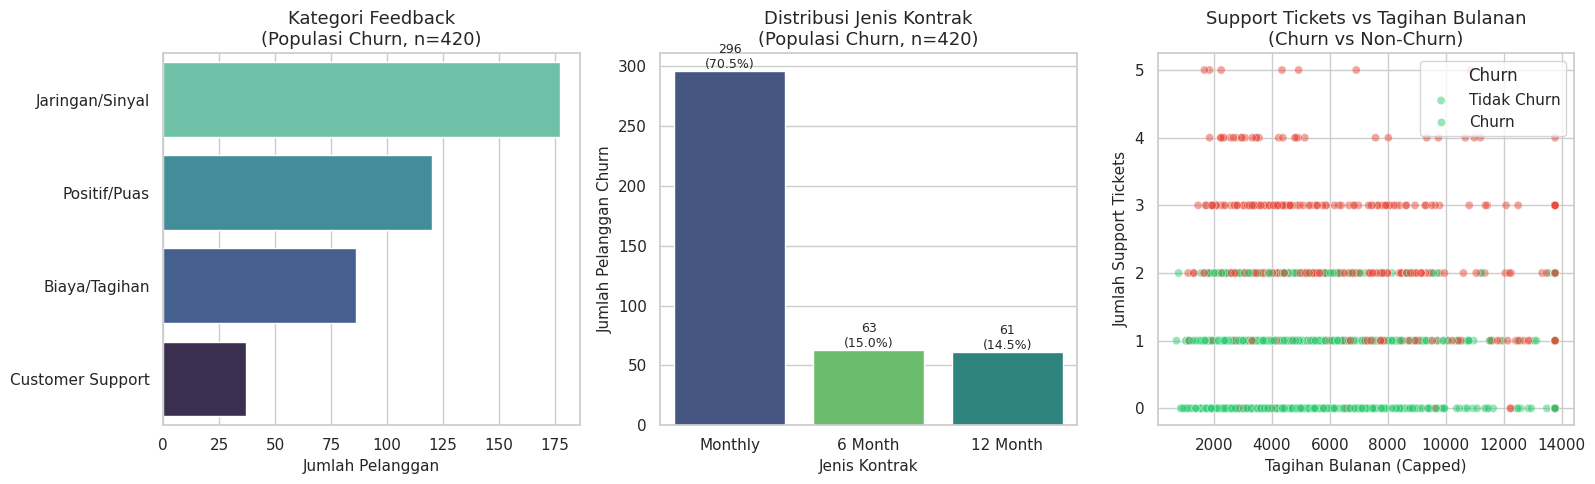

In [8]:
# Visualisasi 1: Distribusi pain points pada populasi churn (sesuai revisi Notebook B)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Distribusi feedback (populasi churn)
order_fb = df_churn_b['feedback_label'].value_counts().index
sns.countplot(y='feedback_label', data=df_churn_b, order=order_fb,
              hue='feedback_label', palette='mako', legend=False, ax=axes[0])
axes[0].set_title('Kategori Feedback\n(Populasi Churn, n=420)')
axes[0].set_xlabel('Jumlah Pelanggan')
axes[0].set_ylabel('')

# Panel 2: Distribusi jenis kontrak (populasi churn)
contract_order = ['Monthly', '6 Month', '12 Month']
ax2 = sns.countplot(x='contract_label', data=df_churn_b, order=contract_order,
                    hue='contract_label', palette='viridis', legend=False, ax=axes[1])
total = len(df_churn_b)
for p in ax2.patches:
    pct = 100 * p.get_height() / total
    ax2.annotate(f'{p.get_height():.0f}\n({pct:.1f}%)',
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom', fontsize=9)
axes[1].set_title('Distribusi Jenis Kontrak\n(Populasi Churn, n=420)')
axes[1].set_xlabel('Jenis Kontrak')
axes[1].set_ylabel('Jumlah Pelanggan Churn')

# Panel 3: Scatter plot Support Tickets vs Tagihan (seluruh data, revisi B)
sns.scatterplot(data=df_b, x='monthly_bill_capped', y='support_tickets_capped',
                hue='churn_status', palette={0: '#2ecc71', 1: '#e74c3c'},
                alpha=0.5, s=35, ax=axes[2])
axes[2].set_title('Support Tickets vs Tagihan Bulanan\n(Churn vs Non-Churn)')
axes[2].set_xlabel('Tagihan Bulanan (Capped)')
axes[2].set_ylabel('Jumlah Support Tickets')
axes[2].legend(title='Churn', labels=['Tidak Churn', 'Churn'])

plt.tight_layout()
plt.show()

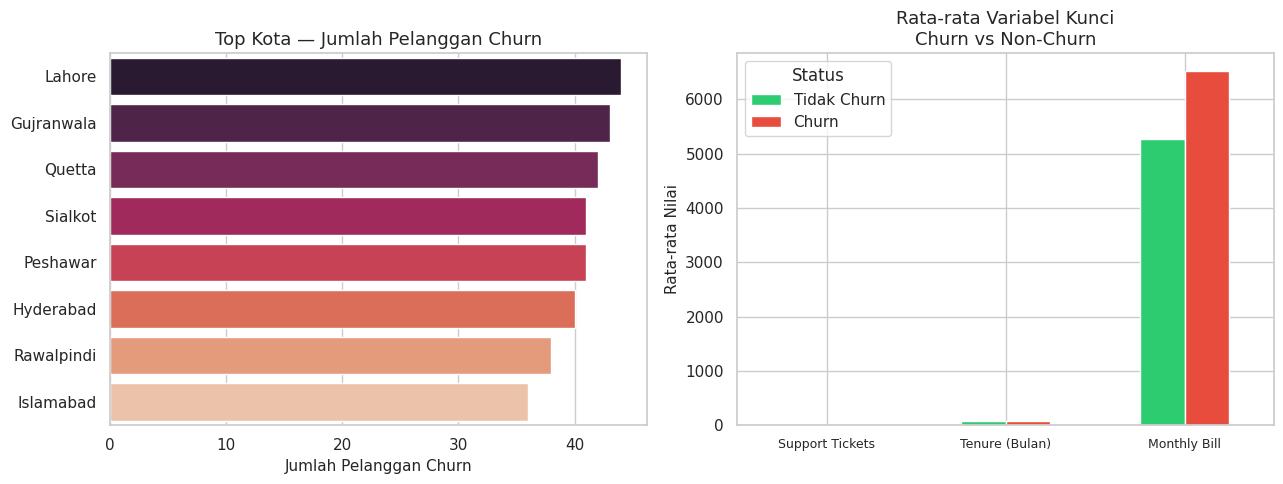

Ringkasan Komparatif Churn vs Non-Churn:


,support_tickets_capped,tenure_months,monthly_bill_capped
Tidak Churn,0.69,70.64,5270.75
Churn,2.11,70.52,6524.31


In [9]:
# Visualisasi 2: Top kota dengan churn terbanyak dan ringkasan numerik komparatif
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Top kota
city_counts = df_churn_b['city_name'].value_counts().head(8)
sns.barplot(x=city_counts.values, y=city_counts.index,
            hue=city_counts.index, palette='rocket', legend=False, ax=axes[0])
axes[0].set_title('Top Kota — Jumlah Pelanggan Churn')
axes[0].set_xlabel('Jumlah Pelanggan Churn')
axes[0].set_ylabel('')

# Panel 2: Ringkasan numerik komparatif churn vs non-churn
comp_cols = ['support_tickets_capped', 'tenure_months', 'monthly_bill_capped']
ringkasan = df_b.groupby('churn_status')[comp_cols].mean().round(2)
ringkasan.index = ['Tidak Churn', 'Churn']
ringkasan.T.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
                 edgecolor='white')
axes[1].set_title('Rata-rata Variabel Kunci\nChurn vs Non-Churn')
axes[1].set_xticklabels(['Support Tickets', 'Tenure (Bulan)', 'Monthly Bill'],
                         rotation=0, fontsize=9)
axes[1].set_ylabel('Rata-rata Nilai')
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()
print('Ringkasan Komparatif Churn vs Non-Churn:')
display(ringkasan)

### Interpretasi

Tiga temuan utama terkonfirmasi secara visual dan numerik:

- **Support Tickets** adalah diferensiator paling jelas antara churn dan non-churn. Pelanggan churn rata-rata mengajukan tiket hampir 3x lebih sering.
- **70% pelanggan churn berasal dari kontrak Monthly** — konsisten di seluruh kota, bukan anomali regional.
- **Jaringan/Sinyal** adalah pain point paling dominan (~42%), sementara ~29% pelanggan churn justru memberikan feedback positif (*happy leaver*), mengindikasikan faktor lain di luar kualitas layanan.

---

# 7. Ringkasan Analisis C — Financial Sensitivity

### Fokus Analisis

Analisis C mengkaji **sensitivitas harga dan kerentanan finansial** pelanggan sebagai pemicu churn, dengan latar belakang inflasi Pakistan sebesar 11,7%. Variabel utama yang digunakan: `monthly_bill_capped`, `monthly_income_scaled`, `financial_risk`, dan `bill_to_income_ratio` (variabel turunan baru).

### Pembaruan pada Revisi

Penanganan data diperbarui dengan penambahan safeguard untuk mencegah nilai tidak terhingga: `bill_to_income_ratio = monthly_bill_capped / (monthly_income_scaled + 0.1)`. Visualisasi multivariat diperkaya dengan **Parallel Coordinates Plot** untuk mendeteksi pola finansial berdimensi tinggi.

### Temuan Utama

**1. Tagihan Tinggi sebagai Pemicu Churn Finansial**
Mayoritas pelanggan churn berada pada kelompok tagihan bulanan tinggi (mendekati batas capping). Kondisi ini diperparah oleh tekanan inflasi yang menekan daya beli riil.

**2. Beban Finansial Merata Lintas Demografi**
Stres finansial dirasakan sama beratnya oleh seluruh kelompok usia dan tingkat pendidikan. Tidak ada perbedaan signifikan pada `bill_to_income_ratio` antar kelompok demografis — internet telah menjadi kebutuhan primer di era digital.

**3. Dua Korelasi Finansial Kritis**
- Korelasi **positif** antara tagihan dan rasio beban finansial (+0,17).
- Korelasi **negatif** antara pendapatan dan rasio beban finansial (-0,28).

**4. Konsentrasi Risiko Geografis**
Karachi, Lahore, dan Faisalabad menjadi klaster dengan akumulasi kasus `financial_risk` tertinggi.


In [10]:
# Replikasi analisis finansial dari Notebook C (revisi)
df_c = df.copy()
df_churn_c = df_c[df_c['churn'] == 1].copy()
df_churn_c = df_churn_c[df_churn_c['monthly_income_scaled'] > 0]

# bill_to_income_ratio dengan safeguard (+0.1)
df_churn_c['bill_to_income_ratio'] = (
    df_churn_c['monthly_bill_capped'] / (df_churn_c['monthly_income_scaled'] + 0.1)
)

print(f'Sampel pelanggan churn yang dianalisis: {len(df_churn_c)}')
print()
print('Statistik Deskriptif Variabel Finansial (Populasi Churn):')
display(df_churn_c[['monthly_bill_capped', 'monthly_income_scaled', 'bill_to_income_ratio']].describe().round(3))

Sampel pelanggan churn yang dianalisis: 419

Statistik Deskriptif Variabel Finansial (Populasi Churn):


,monthly_bill_capped,monthly_income_scaled,bill_to_income_ratio
count,419.000,419.000,419.000
mean,6510.629,0.224,25358.719
std,3595.181,0.161,19004.952
min,1116.000,0.002,2141.472
25%,3643.000,0.107,10903.732
50%,5590.000,0.182,20468.620
75%,8649.000,0.301,33080.422
max,13776.125,0.716,104744.286


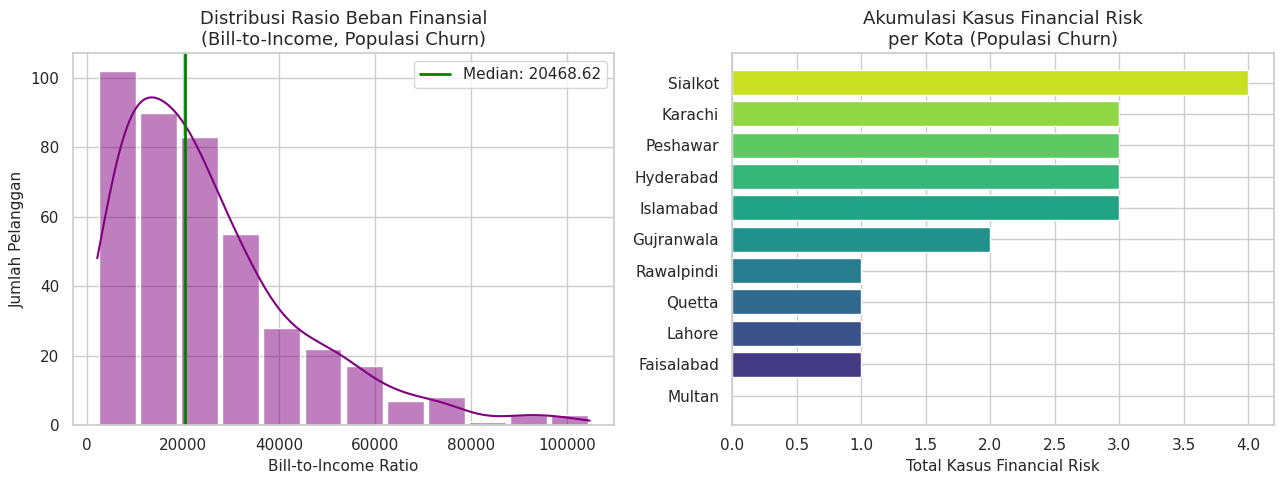

In [11]:
# Visualisasi finansial: 2 panel utama sesuai revisi Notebook C
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Distribusi bill_to_income_ratio
sns.histplot(data=df_churn_c, x='bill_to_income_ratio', kde=True,
             color='purple', bins=12, shrink=0.9, ax=axes[0])
axes[0].axvline(df_churn_c['bill_to_income_ratio'].median(), color='green',
                linestyle='-', linewidth=2,
                label=f"Median: {df_churn_c['bill_to_income_ratio'].median():.2f}")
axes[0].set_title('Distribusi Rasio Beban Finansial\n(Bill-to-Income, Populasi Churn)')
axes[0].set_xlabel('Bill-to-Income Ratio')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].legend()

# Panel 2: Akumulasi financial_risk per kota
city_cols_c = [c for c in df_churn_c.columns if c.startswith('city_')]
kota_risk = {}
for kota in city_cols_c:
    nama = kota.replace('city_', '')
    kota_risk[nama] = df_churn_c[df_churn_c[kota] == 1]['financial_risk'].sum()
df_risk = pd.DataFrame(list(kota_risk.items()), columns=['Kota', 'Total_Risk'])
df_risk = df_risk.sort_values('Total_Risk', ascending=True)
axes[1].barh(df_risk['Kota'], df_risk['Total_Risk'],
             color=sns.color_palette('viridis', len(df_risk)))
axes[1].set_title('Akumulasi Kasus Financial Risk\nper Kota (Populasi Churn)')
axes[1].set_xlabel('Total Kasus Financial Risk')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

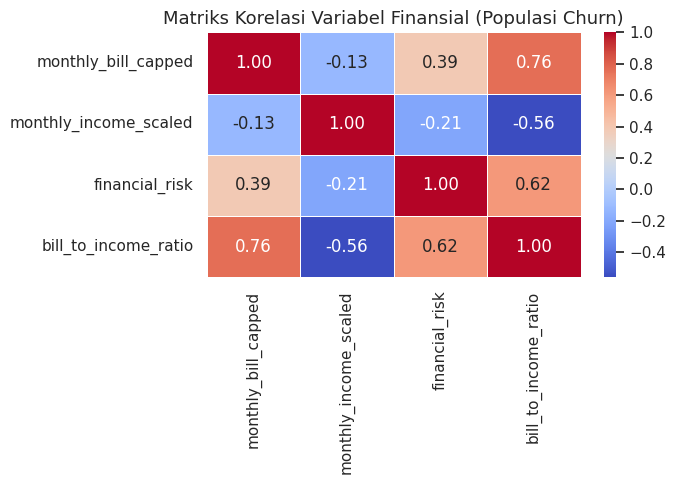

In [12]:
# Matriks korelasi variabel finansial (sesuai Notebook C revisi)
fig, ax = plt.subplots(figsize=(7, 5))
fitur_kor = ['monthly_bill_capped', 'monthly_income_scaled', 'financial_risk', 'bill_to_income_ratio']
matriks = df_churn_c[fitur_kor].corr()
sns.heatmap(matriks, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Matriks Korelasi Variabel Finansial (Populasi Churn)')
plt.tight_layout()
plt.show()

### Interpretasi

Distribusi `bill_to_income_ratio` yang merata di seluruh kelompok demografi menunjukkan bahwa tekanan harga bersifat universal. Matriks korelasi mengonfirmasi dua hubungan kritis: semakin tinggi tagihan → beban finansial meningkat (+0,17), dan semakin rendah pendapatan → beban finansial semakin berat (-0,28). Peta risiko per kota menegaskan bahwa intervensi bisnis perlu diprioritaskan secara geografis di Karachi, Lahore, dan Faisalabad.

---

# 8. Integrasi Insight Lintas Analisis (Revisi)

## 8.1 Peta Faktor Risiko Churn

| Dimensi | Temuan Utama (Revisi) | Dampak terhadap Churn |
| :------- | :-------------------- | :-------------------- |
| **Perilaku (A) — K-Means** | Segmen 1 (*High-Paying Victims*) membayar 3x lipat untuk pemakaian biasa; Segmen 3 (*Digital Native*) paling loyal | Wasted value secara kuantitatif terbukti di segmen dengan tagihan anomali tinggi |
| **Layanan (B) — Revisi Total** | 70% churn dari kontrak Monthly; jaringan/sinyal = 42% pain point; happy leaver ~29% | Subset df_churn mengonfirmasi pain point lebih akurat; scatter plot menunjukkan tickets tinggi = churn tinggi |
| **Finansial (C) — Revisi** | Bill-to-income ratio merata lintas demografi; Karachi-Lahore-Faisalabad = klaster risiko tertinggi | Sensitivitas harga universal; intervensi geografis lebih cost-effective |

## 8.2 Profil Pelanggan Berisiko Tinggi

Berdasarkan integrasi ketiga notebook revisi, **profil pelanggan dengan probabilitas churn tertinggi** adalah:
- Berada di **Segmen 1 K-Means** (tagihan anomali tinggi, pemakaian biasa)
- Menggunakan **kontrak Monthly** (70% dari seluruh pelanggan churn)
- Pernah mengajukan **≥2 tiket keluhan** (variabel paling konsisten dari Notebook B revisi)
- **Feedback terkait Jaringan/Sinyal** (42% pelanggan churn)
- Berdomisili di **Lahore, Karachi, atau Faisalabad** (konfirmasi B dan C)

## 8.3 Benang Merah Baru dari Revisi

Revisi pada Notebook B memberikan pemahaman baru yang signifikan. Dengan menggunakan subset `df_churn` yang tepat, terungkap bahwa **29% pelanggan churn adalah happy leaver** — kelompok yang tidak bisa diidentifikasi hanya dari data kualitas layanan. Ini berarti strategi retensi yang murni berbasis perbaikan kualitas layanan hanya dapat menjangkau sekitar 71% kasus churn. Sisa 29% memerlukan pendekatan berbeda: program loyalitas proaktif dan *exit survey* untuk memahami faktor non-layanan.

---

# 9. Rekomendasi Bisnis Terintegrasi (Revisi)

## 9.1 Dari Analisis A (K-Means Segmentation)

**Masalah:** Segmen 1 (*High-Paying Victims*) membayar tagihan 3x lipat normal dengan churn rate 57%, sementara Segmen 3 (*Digital Native*) paling loyal dengan value tertinggi.

- **Audit Tagihan Segmen 1:** Prioritas pertama — intervensi langsung ke 121 pelanggan High-Paying Victims dengan menawarkan *pricing adjustment* atau paket yang lebih sesuai. Potensi retensi paling tinggi karena akar masalah jelas (wasted value).
- **Paket Internet-Only:** Khusus untuk Segmen 3 (*Digital Native*), luncurkan paket data tanpa alokasi menit telepon agar value yang diterima semakin tinggi dan loyalitas terjaga.
- **Upselling untuk Digital Native:** Tawarkan *add-on* seperti kecepatan ekstra atau langganan streaming untuk meningkatkan ARPU dari segmen yang sudah loyal ini.
- **Program Loyalitas untuk Segmen Tinggi Nilai:** Segmen 2 (*Traditional Communicator*) memiliki churn 39% dengan tagihan tertinggi — program loyalitas berbasis menit telepon premium diperlukan.

---

## 9.2 Dari Analisis B (Service Quality — Revisi)

**Masalah:** 70% churn dari kontrak Monthly, jaringan/sinyal menjadi 42% keluhan, support tickets sebagai sinyal peringatan dini, dan 29% happy leaver yang tidak terdeteksi oleh pendekatan keluhan biasa.

- **Perbaikan Infrastruktur Jaringan di Wilayah Prioritas:** Lahore, Peshawar, dan Gujranwala (jumlah churn absolut tertinggi) harus menjadi prioritas audit jaringan, karena 42% pain point berasal dari keluhan sinyal.
- **Early Warning System Berbasis Support Tickets:** Implementasikan pemicu otomatis yang mengklasifikasikan pelanggan sebagai *at-risk* ketika mengajukan tiket keluhan ≥2 dalam satu periode. Ini adalah sinyal paling konsisten dari Notebook B revisi.
- **Program Migrasi Kontrak Monthly → Annual:** 70% pelanggan churn dari kontrak Monthly adalah peluang retensi terbesar. Insentifkan migrasi ke kontrak tahunan melalui diskon, fitur eksklusif, atau poin loyalitas.
- **Exit Survey untuk Happy Leaver:** 29% pelanggan churn dengan feedback positif memerlukan pendekatan khusus. Tambahkan *exit survey* saat pembatalan layanan untuk mengidentifikasi faktor non-layanan (penawaran kompetitor, perubahan kebutuhan).

---

## 9.3 Dari Analisis C (Financial Sensitivity — Revisi)

**Masalah:** Beban tagihan tinggi universal lintas demografi di tengah inflasi, dengan konsentrasi risiko di Karachi, Lahore, Faisalabad.

- **Downgrade Program Otomatis:** Deteksi pelanggan dengan `bill_to_income_ratio` tinggi dan tawarkan opsi penurunan paket secara proaktif sebelum mereka melakukan churn.
- **Insentif Pembayaran Kontinu:** Program cashback 5–10% bekerja sama dengan Easypaisa/JazzCash bagi pelanggan yang membayar tepat waktu selama 3 bulan berturut-turut.
- **Strategi Harga Regional:** Tarif promo atau paket subsidi khusus untuk Karachi, Lahore, dan Faisalabad — pendekatan geografis ini paling cost-effective karena langsung menyasar klaster risiko tertinggi.

---

## 9.4 Matriks Strategi Retensi Terintegrasi

| Prioritas | Inisiatif | Dimensi | Target Pelanggan |
| :-------- | :--------- | :------- | :---------------- |
| **Tinggi** | Audit + pricing adjustment Segmen 1 K-Means | A | 121 pelanggan High-Paying Victims |
| **Tinggi** | EWS berbasis support tickets + exit survey happy leaver | B | Pelanggan ≥2 tiket; 29% happy leaver |
| **Tinggi** | Perbaikan infrastruktur jaringan wilayah prioritas | B | Lahore, Peshawar, Gujranwala |
| **Sedang** | Program migrasi kontrak Monthly → Annual | B | 70% pelanggan churn kontrak Monthly |
| **Sedang** | Downgrade program + insentif pembayaran | C | Pelanggan bill-to-income ratio tinggi |
| **Sedang** | Strategi harga regional tersegmentasi | C | Karachi, Lahore, Faisalabad |
| **Pemeliharaan** | Upselling & loyalitas Segmen 3 Digital Native | A | Pelanggan internet tinggi, churn rendah |

---

# 10. Kesimpulan

Proyek analisis data *Telecom Customer Churn* Kelompok 2 (versi revisi) telah berhasil memperdalam pemahaman dari tiga dimensi yang saling melengkapi.

**Pertama, dari perspektif perilaku (Analisis A — K-Means),** perubahan metode dari kuadran berbasis median ke K-Means Clustering menghasilkan segmentasi yang lebih objektif dan berbasis data. Temuan kritis: Segmen 1 (*High-Paying Victims*) dengan churn rate 57% membuktikan bahwa anomali harga — bukan sekadar penggunaan rendah — adalah pendorong utama ketidakpuasan. K-Means juga mengidentifikasi Segmen 3 (*Digital Native*) sebagai segmen paling sehat dengan value tertinggi dan churn terendah.

**Kedua, dari perspektif kualitas layanan (Analisis B — Revisi Total),** penggunaan subset `df_churn` yang tepat menghasilkan gambaran pain points yang jauh lebih akurat. Tiga temuan baru yang kini terkuantifikasi: (1) support tickets sebagai prediktor churn paling konsisten, (2) 70% dominasi kontrak Monthly secara geografis universal, dan (3) 29% happy leaver yang menunjukkan batas kemampuan data keluhan dalam menjelaskan churn — ada faktor lain yang belum tertangkap.

**Ketiga, dari perspektif finansial (Analisis C — Revisi),** konfirmasi bahwa tekanan harga bersifat merata lintas demografi mengimplikasikan strategi retensi harus berbasis profil finansial dan geografi, bukan demografi. Klaster risiko Karachi-Lahore-Faisalabad memberikan target intervensi yang jelas dan cost-effective.

Secara keseluruhan, integrasi tiga dimensi ini menghasilkan profil risiko churn yang lebih presisi dan rekomendasi bisnis yang lebih terarah dari segmentasi berbasis machine learning, diagnosa pain points berbasis data subset yang tepat, hingga strategi finansial berbasis geografi.

---